In [3]:
import pandas as pd
import numpy as np
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn import metrics
from sklearn.metrics import roc_curve
from sklearn.metrics import recall_score, confusion_matrix, precision_score, f1_score, accuracy_score, classification_report

In [5]:
# import data

In [6]:
df = pd.read_csv('../data/Telco_Customer_Churn.csv')


In [7]:
df.shape

(7043, 21)

In [8]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [10]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [11]:
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

In [12]:
#check null values

<Axes: >

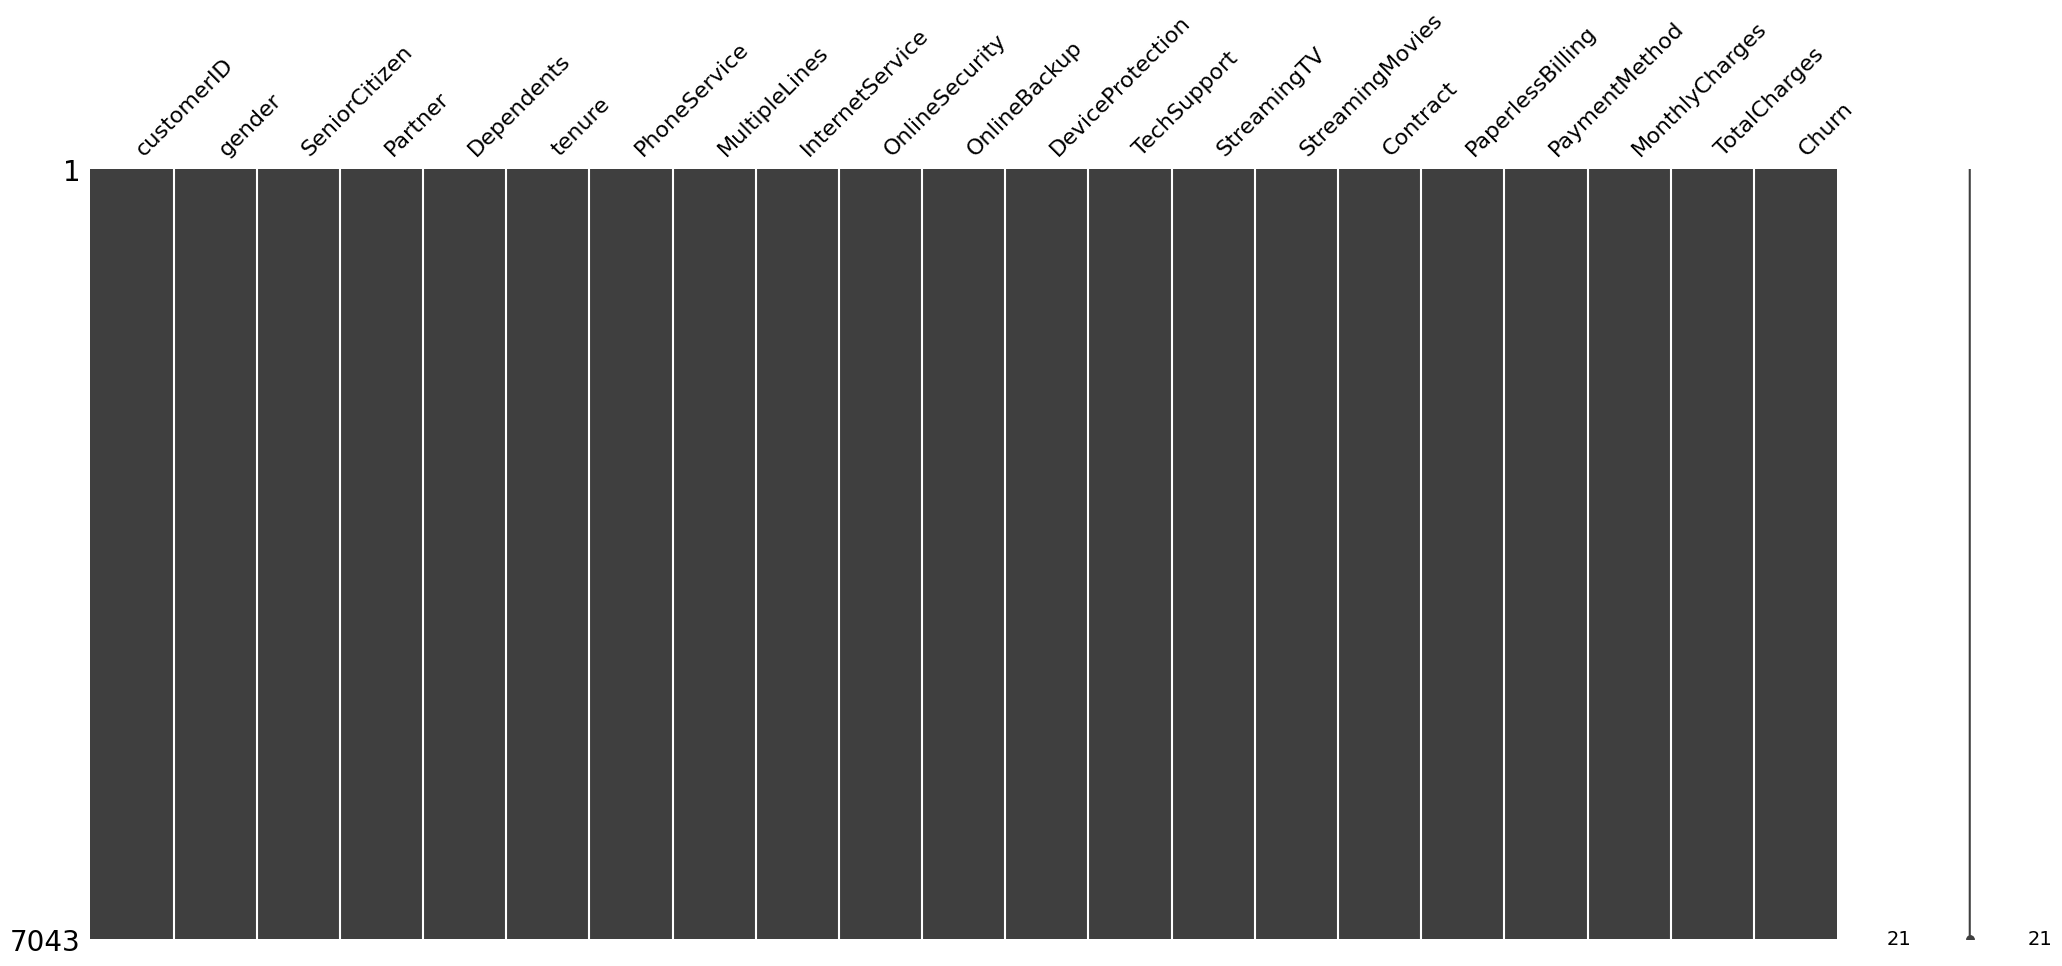

In [13]:
msno.matrix(df)

In [14]:
#there are no missing values in the data

In [15]:
df['TotalCharges'] = pd.to_numeric(df.TotalCharges, errors='coerce')
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [16]:
#Here we see that the TotalCharges has 11 missing values. Let's check this data.


In [17]:
df[np.isnan(df['TotalCharges'])]


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [ ]:
#Tenure column is 0 for these entries even though the MonthlyCharges column is not empty.

In [18]:
df[df['tenure'] == 0].index

Index([488, 753, 936, 1082, 1340, 3331, 3826, 4380, 5218, 6670, 6754], dtype='int64')

In [19]:
#Delete the rows with missing values in Tenure columns since there are only 11 rows and deleting them will not affect the data.



In [20]:
df.drop(labels=df[df['tenure'] == 0].index, axis=0, inplace=True)
df[df['tenure'] == 0].index

Index([], dtype='int64')

In [21]:
df[np.isnan(df['TotalCharges'])]


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


In [22]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [24]:
df["InternetService"].value_counts()

InternetService
Fiber optic    3096
DSL            2416
No             1520
Name: count, dtype: int64

In [25]:
df["InternetService"].describe(include=['object', 'bool'])

count            7032
unique              3
top       Fiber optic
freq             3096
Name: InternetService, dtype: object

In [26]:
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
df[numerical_cols].describe()

,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000
mean,32.421786,64.798208,2283.300441
std,24.545260,30.085974,2266.771362
min,1.000000,18.250000,18.800000
25%,9.000000,35.587500,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.862500,3794.737500
max,72.000000,118.750000,8684.800000


In [27]:
# Visualizing data

In [28]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

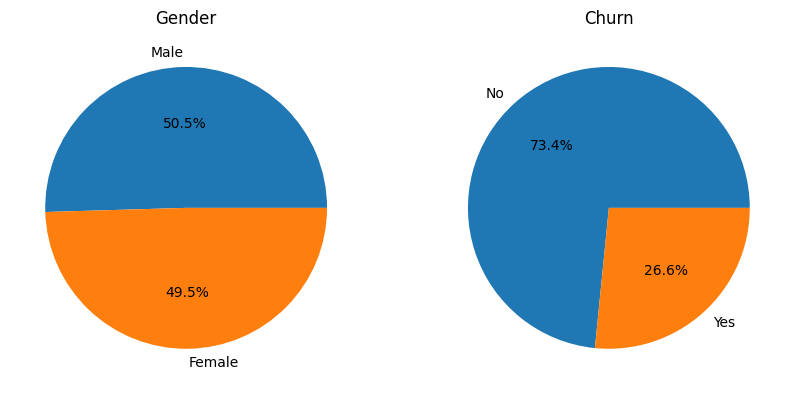

In [31]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(10,5))

df['gender'].value_counts().plot.pie(ax=ax[0], autopct='%1.1f%%')
ax[0].set_title('Gender')

df['Churn'].value_counts().plot.pie(ax=ax[1], autopct='%1.1f%%')
ax[1].set_title('Churn')

plt.show()

In [33]:
# Observation: Around 25% customers have churned, indicating class imbalance.

In [35]:
pd.crosstab(df['gender'], df['Churn'])

Churn,No,Yes
gender,,
Female,2544,939
Male,2619,930


In [36]:
pd.crosstab(df['gender'], df['Churn'], normalize='index') * 100

Churn,No,Yes
gender,,
Female,73.040482,26.959518
Male,73.795435,26.204565


In [37]:
# Both genders behaved in similar fashion when it comes to migrating to another service provider.

In [41]:
pd.crosstab(df['Contract'], df['Churn'])

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1306,166
Two year,1637,48


In [42]:
pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.722826,11.277174
Two year,97.151335,2.848665


In [43]:
# Customers without long-term commitment are more likely to leave
# Focus retention strategies on month-to-month users

In [45]:
px.pie(df, names='PaymentMethod', title='Payment Method Distribution').show()

In [46]:
pd.crosstab(df['PaymentMethod'], df['Churn'], normalize='index') * 100

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.268482,16.731518
Credit card (automatic),84.746877,15.253123
Electronic check,54.714588,45.285412
Mailed check,80.798005,19.201995


In [ ]:
# Major customers who moved out were having Electronic Check as Payment Method.

In [48]:
pd.crosstab(
    [df['gender'], df['InternetService']],
    df['Churn'],
    normalize='index'
) * 100

Churn                          No        Yes
gender InternetService                      
Female DSL              81.503378  18.496622
       Fiber optic      57.244044  42.755956
       No               92.493298   7.506702
Male   DSL              80.519481  19.480519
       Fiber optic      58.976021  41.023979
       No               92.635659   7.364341

In [49]:
# Internet service type significantly impacts churn
# Fiber optic users have most churn rate in both genders

In [50]:
import plotly.express as px

fig = px.histogram(
    df,
    x="Churn",
    color="InternetService",
    facet_col="gender"
)

fig.show()

In [52]:
px.histogram(df, x="Churn", color="Dependents",
             title="Dependents Distribution").show()

In [53]:
pd.crosstab(df['Dependents'], df['Churn'], normalize='index') * 100

Churn,No,Yes
Dependents,,
No,68.720860,31.279140
Yes,84.468795,15.531205


In [54]:
# Customers without dependents have higher churn
# Family/long-term responsibility may reduce churn likelihood

In [56]:
px.histogram(df, x="Churn", color="Partner",
             title="Partners Distribution").show()

In [57]:
pd.crosstab(df['Partner'], df['Churn'], normalize='index') * 100

Churn,No,Yes
Partner,,
No,67.023908,32.976092
Yes,80.282935,19.717065


In [58]:
# Customers that don't have partners are more likely to churn

In [61]:
px.histogram(df, x="Churn", color="SeniorCitizen",
             title="SeniorCitizen Distribution").show()

In [62]:
pd.crosstab(df['SeniorCitizen'], df['Churn'], normalize='index') * 100

Churn,No,Yes
SeniorCitizen,,
0,76.349745,23.650255
1,58.318739,41.681261


In [ ]:
# It is observed that the fraction of senior citizen is very less.
# Many of the senior citizens churn.

In [64]:
px.histogram(df, x="Churn", color="OnlineSecurity",
             title="OnlineSecurity Distribution").show()

In [65]:
pd.crosstab(df['OnlineSecurity'], df['Churn'], normalize='index') * 100

Churn,No,Yes
OnlineSecurity,,
No,58.221333,41.778667
No internet service,92.565789,7.434211
Yes,85.359801,14.640199


In [66]:
# Most customers churn in the absence of online security,

In [67]:
px.histogram(df, x="Churn", color="PaperlessBilling",
             title="PaperlessBilling Distribution").show()

In [68]:
pd.crosstab(df['PaperlessBilling'], df['Churn'], normalize='index') * 100

Churn,No,Yes
PaperlessBilling,,
No,83.624302,16.375698
Yes,66.410749,33.589251


In [69]:
# Customers with Paperless Billing are most likely to churn.

In [70]:
px.histogram(df, x="Churn", color="TechSupport",
             title="TechSupport Distribution").show()

In [71]:
pd.crosstab(df['TechSupport'], df['Churn'], normalize='index') * 100

Churn,No,Yes
TechSupport,,
No,58.352535,41.647465
No internet service,92.565789,7.434211
Yes,84.803922,15.196078


In [72]:
# Customers with no TechSupport are most likely to migrate to another service provider.

In [73]:
px.histogram(df, x="Churn", color="PhoneService",
             title="PhoneService Distribution").show()

In [74]:
pd.crosstab(df['PhoneService'], df['Churn'], normalize='index') * 100

Churn,No,Yes
PhoneService,,
No,75.000000,25.000000
Yes,73.252519,26.747481


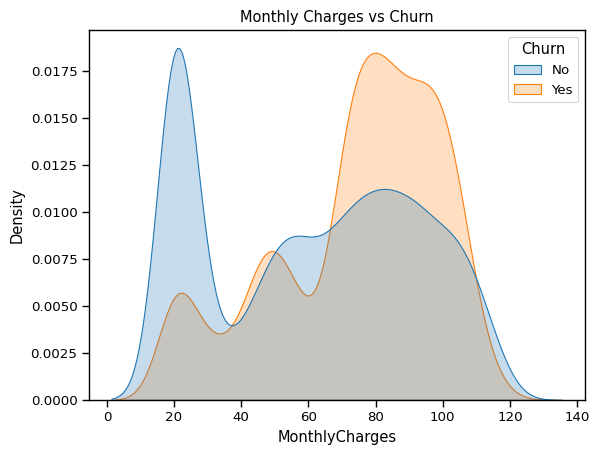

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.kdeplot(
    data=df,
    x="MonthlyCharges",
    hue="Churn",
    fill=True,
    common_norm=False
)

plt.title("Monthly Charges vs Churn")
plt.show()

In [80]:
#Customers with higher Monthly Charges are also more likely to churn

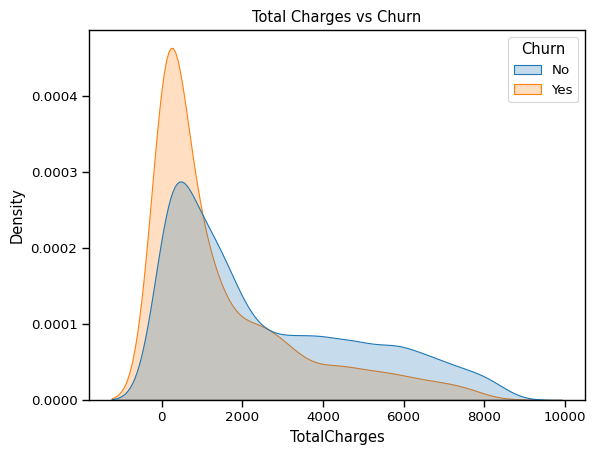

In [79]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.kdeplot(
    data=df,
    x="TotalCharges",
    hue="Churn",
    fill=True,
    common_norm=False
)

plt.title("Total Charges vs Churn")
plt.show()

In [82]:
px.box(df, x='Churn', y='tenure',
       title='Tenure vs Churn').show()

In [83]:
#New customers are more likely to churn

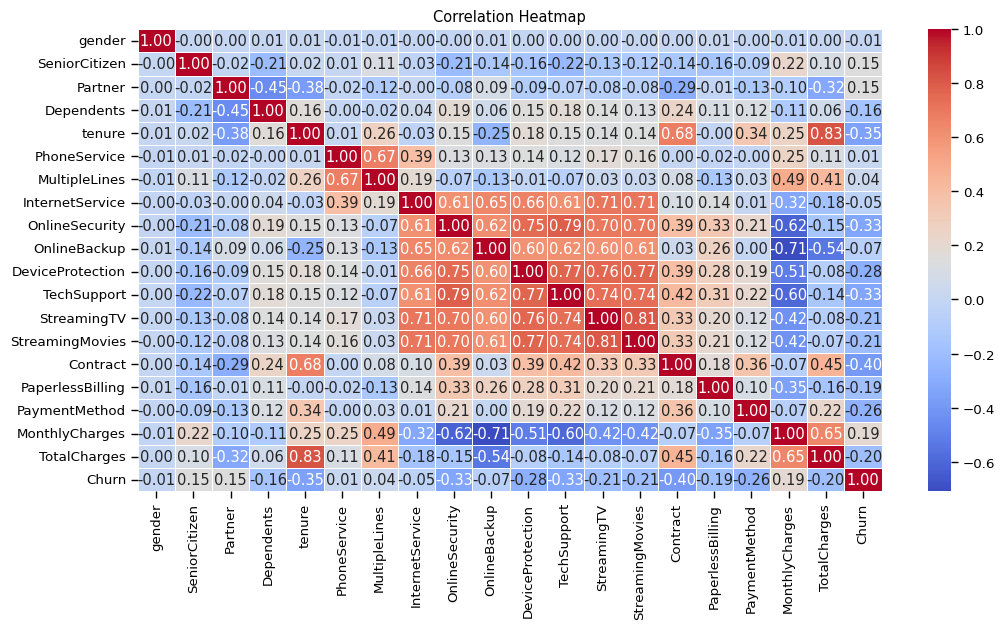

In [94]:
import seaborn as sns
import matplotlib.pyplot as plt

#df = df.drop(columns='customerID')

df_encoded = df.copy()
for col in df_encoded.select_dtypes(include='object'):
    df_encoded[col] = pd.factorize(df_encoded[col])[0]

plt.figure(figsize=(12, 6))
sns.heatmap(df_encoded.corr(), cmap='coolwarm', annot=True, fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

In [96]:
df_encoded.corr()['Churn'].sort_values(ascending=False)

Churn               1.000000
MonthlyCharges      0.192858
SeniorCitizen       0.150541
Partner             0.149982
MultipleLines       0.036148
PhoneService        0.011691
gender             -0.008545
InternetService    -0.047097
OnlineBackup       -0.073934
Dependents         -0.163128
PaperlessBilling   -0.191454
TotalCharges       -0.199484
StreamingTV        -0.205246
StreamingMovies    -0.207150
PaymentMethod      -0.262918
DeviceProtection   -0.281048
TechSupport        -0.329474
OnlineSecurity     -0.332443
tenure             -0.354049
Contract           -0.396150
Name: Churn, dtype: float64

In [98]:
df.to_csv('../data/Telco_Customer_Churn_cleaned.csv', index=False)